# Task 2: Classification with Logistic Regression

# 🛒 Customer Purchase Prediction Using Machine Learning

## Project Overview

This project builds and evaluates classification models to predict
whether a customer will make a purchase based on customer behavior
and demographic information.

Logistic Regression and Random Forest Classification models are
trained and compared using multiple classification metrics.

## Objectives

- Prepare customer data for classification
- Identify features and target variable
- Split data into training and testing sets
- Scale numerical features
- Train a Logistic Regression model
- Evaluate the model using Accuracy, Precision, Recall and ROC-AUC
- Visualize the ROC curve
- Train a Random Forest classifier
- Compare model performance
- Generate business insights

## Tools Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Google Colab

# Step 2 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Step 3 — Create the Customer Dataset

In [4]:
data = {
    "Age": [
        22, 25, 28, 31, 35,
        38, 42, 45, 29, 33,
        27, 41, 36, 50, 24,
        39, 44, 30, 26, 48,
        34, 37, 23, 32, 40
    ],

    "Annual_Income": [
        25000, 32000, 41000, 48000, 55000,
        62000, 75000, 82000, 45000, 52000,
        38000, 71000, 59000, 95000, 29000,
        68000, 78000, 47000, 35000, 88000,
        54000, 64000, 28000, 50000, 72000
    ],

    "Website_Visits": [
        2, 3, 4, 5, 6,
        7, 9, 10, 5, 6,
        3, 8, 7, 11, 2,
        8, 9, 5, 4, 10,
        6, 7, 2, 5, 9
    ],

    "Previous_Purchases": [
        0, 1, 1, 2, 3,
        4, 5, 6, 2, 3,
        1, 5, 4, 7, 0,
        5, 6, 2, 1, 6,
        3, 4, 0, 2, 5
    ],

    "Purchased": [
        0, 0, 0, 1, 1,
        1, 1, 1, 0, 1,
        0, 1, 1, 1, 0,
        1, 1, 0, 0, 1,
        1, 1, 0, 1, 1
    ]
}

df = pd.DataFrame(data)

df.head()

,Age,Annual_Income,Website_Visits,Previous_Purchases,Purchased
0,22,25000,2,0,0
1,25,32000,3,1,0
2,28,41000,4,1,0
3,31,48000,5,2,1
4,35,55000,6,3,1


# Step 4 — Understand the Dataset

In [5]:
df.shape

(25, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 25 non-null     int64
 1   Annual_Income       25 non-null     int64
 2   Website_Visits      25 non-null     int64
 3   Previous_Purchases  25 non-null     int64
 4   Purchased           25 non-null     int64
dtypes: int64(5)
memory usage: 1.1 KB


In [7]:
df.describe()

,Age,Annual_Income,Website_Visits,Previous_Purchases,Purchased
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,34.360000,55720.000000,6.120000,3.120000,0.640000
std,7.968061,19537.400032,2.682039,2.127596,0.489898
min,22.000000,25000.000000,2.000000,0.000000,0.000000
25%,28.000000,41000.000000,4.000000,1.000000,0.000000
50%,34.000000,54000.000000,6.000000,3.000000,1.000000
75%,40.000000,71000.000000,8.000000,5.000000,1.000000
max,50.000000,95000.000000,11.000000,7.000000,1.000000


In [8]:
df.isnull().sum()

,0
Age,0
Annual_Income,0
Website_Visits,0
Previous_Purchases,0
Purchased,0


# Step 5 — Check Target Distribution

In [9]:
df["Purchased"].value_counts()

,count
Purchased,
1,16
0,9


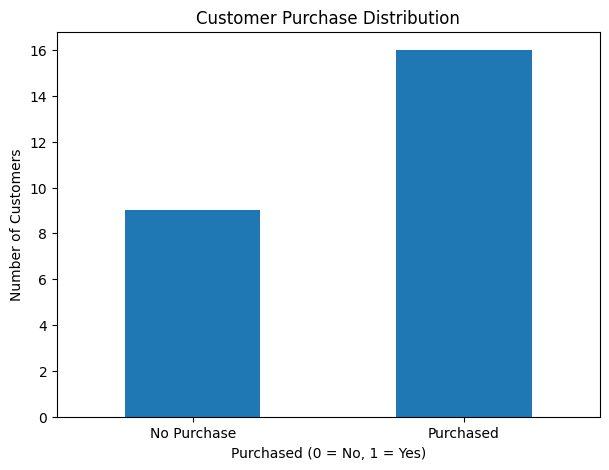

In [10]:
plt.figure(figsize=(7, 5))

df["Purchased"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Purchase Distribution")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.xticks(
    ticks=[0, 1],
    labels=["No Purchase", "Purchased"],
    rotation=0
)

plt.show()

# Step 6 — Separate Features and Target

In [11]:
X = df[
    [
        "Age",
        "Annual_Income",
        "Website_Visits",
        "Previous_Purchases"
    ]
]

y = df["Purchased"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Annual_Income  Website_Visits  Previous_Purchases
0   22          25000               2                   0
1   25          32000               3                   1
2   28          41000               4                   1
3   31          48000               5                   2
4   35          55000               6                   3

Target:
0    0
1    0
2    0
3    1
4    1
Name: Purchased, dtype: int64


# Step 7 — Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (20, 4)
Testing features: (5, 4)
Training target: (20,)
Testing target: (5,)


# Step 8 — Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled[:5])

Scaled training data:
[[ 0.38765744  0.4700034   0.37482076  0.48705679]
 [ 1.00298672  1.01421786  1.08876506  0.95092039]
 [ 1.74138185  1.6573804   1.44573722  1.414784  ]
 [-0.71993525 -0.66789957 -0.6960957  -0.90453403]
 [-1.33526453 -1.31106211 -1.41004    -1.36839764]]


# Step 9 — Train Logistic Regression

In [14]:
logistic_model = LogisticRegression(
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predicted classes:")
print(y_pred_logistic)

print("\nPredicted probabilities:")
print(y_prob_logistic)

Predicted classes:
[1 1 1 1 1]

Predicted probabilities:
[0.96955184 0.99256062 0.62335021 0.9980535  0.57609079]


# Step 10 — Evaluate Logistic Regression

In [15]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("ROC-AUC  :", roc_auc_logistic)

Logistic Regression Performance
--------------------------------
Accuracy : 0.6
Precision: 0.6
Recall   : 1.0
ROC-AUC  : 1.0


# Step 11 — Classification Report

In [16]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Purchase", "Purchased"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Purchase       0.00      0.00      0.00         2
   Purchased       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



In [17]:
df['Purchased'].sum()

np.int64(16)

# Step 12 — Confusion Matrix

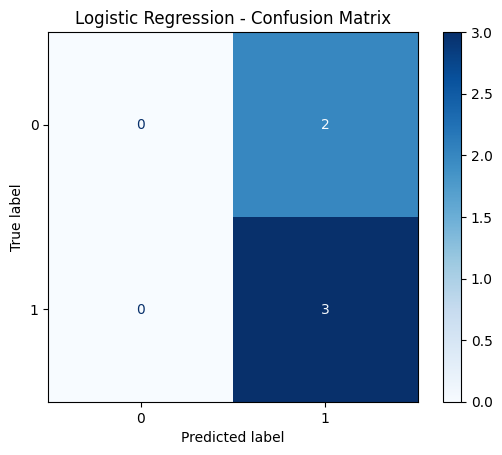

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Step 13 — ROC Curve 📈

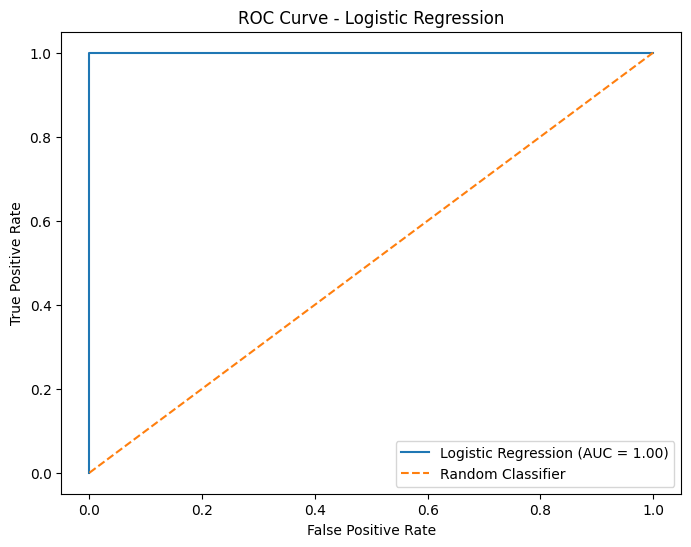

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability for positive class
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Step 14 — Random Forest Classifier 🌲

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test_scaled)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Step 15 — Compare Logistic Regression vs Random Forest 🏆

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, y_pred_logistic)
log_precision = precision_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
log_recall = recall_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
log_f1 = f1_score(y_test, y_pred_logistic, average="weighted", zero_division=0)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average="weighted", zero_division=0)

# Comparison table
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.60,0.60
1,Precision,0.36,0.36
2,Recall,0.60,0.60
3,F1 Score,0.45,0.45


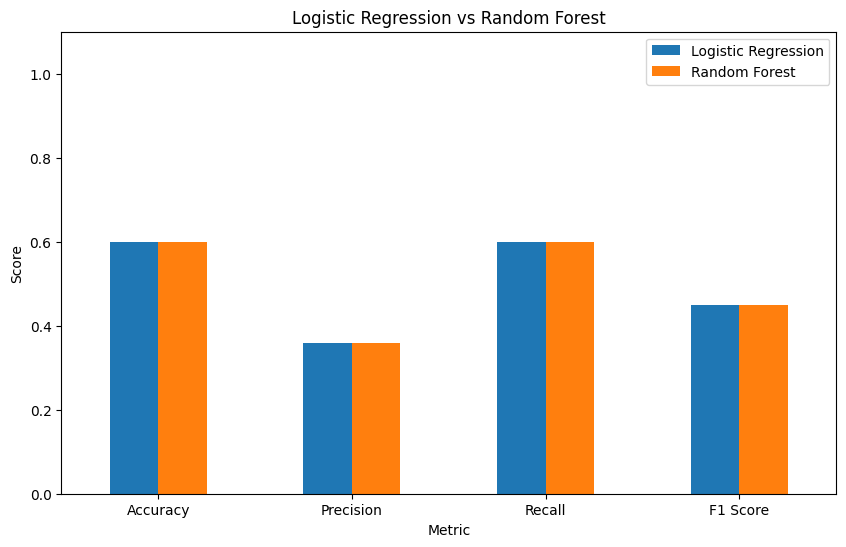

In [22]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [23]:
if rf_accuracy > log_accuracy:
    print("🏆 Random Forest performed better.")
elif log_accuracy > rf_accuracy:
    print("🏆 Logistic Regression performed better.")
else:
    print("🤝 Both models have the same accuracy.")

🤝 Both models have the same accuracy.


In [28]:
from google.colab import files

df.to_csv("customer_purchase_classification.csv", index=False)

files.download("customer_purchase_classification.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Classification Model Comparison — Logistic Regression vs Random Forest

## 📌 Project Overview

This project demonstrates a complete **machine learning classification workflow** using Python and scikit-learn.

The project builds and evaluates two classification models:

* **Logistic Regression**
* **Random Forest Classifier**

The models are evaluated and compared using multiple performance metrics to determine which model performs better on the given dataset.

---

## 🎯 Project Objective

The main objective of this project is to understand and implement a practical classification workflow, including:

* Data preprocessing
* Target distribution analysis
* Feature and target separation
* Train-test splitting
* Feature scaling
* Logistic Regression
* Confusion Matrix
* ROC Curve
* Random Forest Classification
* Model evaluation
* Model comparison

---

## 🛠️ Technologies Used

* Python
* Google Colab
* Pandas
* NumPy
* Scikit-learn
* Matplotlib

---

## 🔄 Machine Learning Workflow

```text
Dataset
   ↓
Data Exploration
   ↓
Data Preprocessing
   ↓
Target Distribution
   ↓
Separate Features & Target
   ↓
Train-Test Split
   ↓
Feature Scaling
   ↓
Logistic Regression
   ↓
Model Evaluation
   ↓
Confusion Matrix
   ↓
ROC Curve
   ↓
Random Forest
   ↓
Model Comparison
   ↓
Final Model Selection
```

---

## 📊 Models Used

### 1. Logistic Regression

Logistic Regression is used as the baseline classification model.

It predicts the probability of an observation belonging to a particular class.

The model is evaluated using:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix
* ROC Curve
* AUC

### 2. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

The model is evaluated using:

* Accuracy
* Precision
* Recall
* F1-score

---

## 📈 Evaluation Metrics

### Accuracy

Measures the percentage of predictions that are correct.

```text
Accuracy = Correct Predictions / Total Predictions
```

### Precision

Measures how many predicted positive observations were actually positive.

### Recall

Measures how many actual positive observations were correctly identified.

### F1 Score

F1-score combines precision and recall into a single metric.

### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

### ROC Curve

The ROC curve evaluates the model's ability to distinguish between classes.

The project also calculates the **AUC (Area Under the Curve)**.

---

## 🏆 Model Comparison

The Logistic Regression and Random Forest models are compared using:

| Metric    |    Logistic Regression |          Random Forest |
| --------- | ---------------------: | ---------------------: |
| Accuracy  | Calculated in notebook | Calculated in notebook |
| Precision | Calculated in notebook | Calculated in notebook |
| Recall    | Calculated in notebook | Calculated in notebook |
| F1 Score  | Calculated in notebook | Calculated in notebook |

The final model selection is based on the evaluation results generated during the notebook execution.

---

## 📁 Project Structure

```text
classification-model-comparison/
│
├── Classification_Model_Comparison.ipynb
├── README.md
└── requirements.txt
```

---

## 🚀 How to Run the Project

### Option 1 — Google Colab

Open the `.ipynb` file using Google Colab and run the notebook cells sequentially.

### Option 2 — Local Environment

Clone the repository:

```bash
git clone YOUR_REPOSITORY_URL
```

Install the required libraries:

```bash
pip install -r requirements.txt
```

Then open the notebook using Jupyter Notebook or JupyterLab.

---

## 📦 Requirements

The main libraries used in this project are:

```text
pandas
numpy
scikit-learn
matplotlib
```

---

## 💡 Key Learning Outcomes

Through this project, I practiced:

* Preparing data for machine learning
* Splitting data into training and testing sets
* Scaling numerical features
* Building classification models
* Evaluating machine learning models
* Understanding confusion matrices
* Understanding ROC curves and AUC
* Comparing different machine learning algorithms
* Selecting a model based on performance metrics

---

## 🔮 Future Improvements

Possible improvements for this project include:

* Hyperparameter tuning
* Cross-validation
* Support Vector Machine (SVM)
* Feature importance analysis
* Hyperparameter optimization using GridSearchCV
* Additional classification algorithms
* Deployment of the final model

---

## 👨‍💻 Author

**Arya Marale**

This project was created as part of my practical learning journey in **Data Analysis and Machine Learning with Python**.
